<div style="width: 150px; float: left;"> <img src="https://raw.githubusercontent.com/DataForScience/Networks/master/data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0" width=150px> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Automate The Boring Stuff With LLMs</h1>
<h1>ChatBot: Wikipedia RAG with Tool Use</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import os
import json
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from tqdm.notebook import tqdm
tqdm.pandas()

from typing import List

from langchain_anthropic import ChatAnthropic
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Local embeddings — no extra API needed
from sentence_transformers import SentenceTransformer

# Vector DB
import chromadb
from chromadb.config import Settings

from datasets import load_dataset

import watermark

%load_ext watermark
%matplotlib inline

We start by print out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.13.0

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 223f278acfc4ab655434a2c518c404972783661f

chromadb                : 1.1.1
datasets                : 4.8.5
json                    : 2.0.9
langchain_anthropic     : 1.4.2
langchain_core          : 1.3.2
langchain_text_splitters: 1.1.2
matplotlib              : 3.10.9
numpy                   : 2.4.4
pandas                  : 3.0.2
sentence_transformers   : 5.4.1
tqdm                    : 4.67.3
watermark               : 2.6.0



Load default figure style

In [3]:
plt.style.use("d4sci.mplstyle")
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Setup

In [4]:
MODEL = 'claude-opus-4-5'
llm = ChatAnthropic(model=MODEL, temperature=0, max_tokens=1024)

# Embeddings

We use a small open-weights model — no extra API key, instant reproducibility. Swap for `voyage-3-lite` (`langchain-voyageai`) in production for higher quality.

In [5]:
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
vec = embedder.encode(['hello world'])
vec.shape

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(1, 384)

In [6]:
vec

array([[-3.44772749e-02,  3.10231932e-02,  6.73495093e-03,
         2.61090212e-02, -3.93620245e-02, -1.60302475e-01,
         6.69239759e-02, -6.44144183e-03, -4.74505089e-02,
         1.47588896e-02,  7.08753690e-02,  5.55275716e-02,
         1.91932973e-02, -2.62513254e-02, -1.01095354e-02,
        -2.69405283e-02,  2.23074146e-02, -2.22266652e-02,
        -1.49692640e-01, -1.74930803e-02,  7.67620886e-03,
         5.43523096e-02,  3.25446343e-03,  3.17259878e-02,
        -8.46214071e-02, -2.94059776e-02,  5.15956469e-02,
         4.81240004e-02, -3.31480312e-03, -5.82791790e-02,
         4.19692695e-02,  2.22107209e-02,  1.28188804e-01,
        -2.23389044e-02, -1.16562909e-02,  6.29283786e-02,
        -3.28763202e-02, -9.12260562e-02, -3.11752651e-02,
         5.26995324e-02,  4.70348373e-02, -8.42030719e-02,
        -3.00561767e-02, -2.07448304e-02,  9.51781310e-03,
        -3.72174568e-03,  7.34333321e-03,  3.93243507e-02,
         9.32740346e-02, -3.78855690e-03, -5.27420975e-0

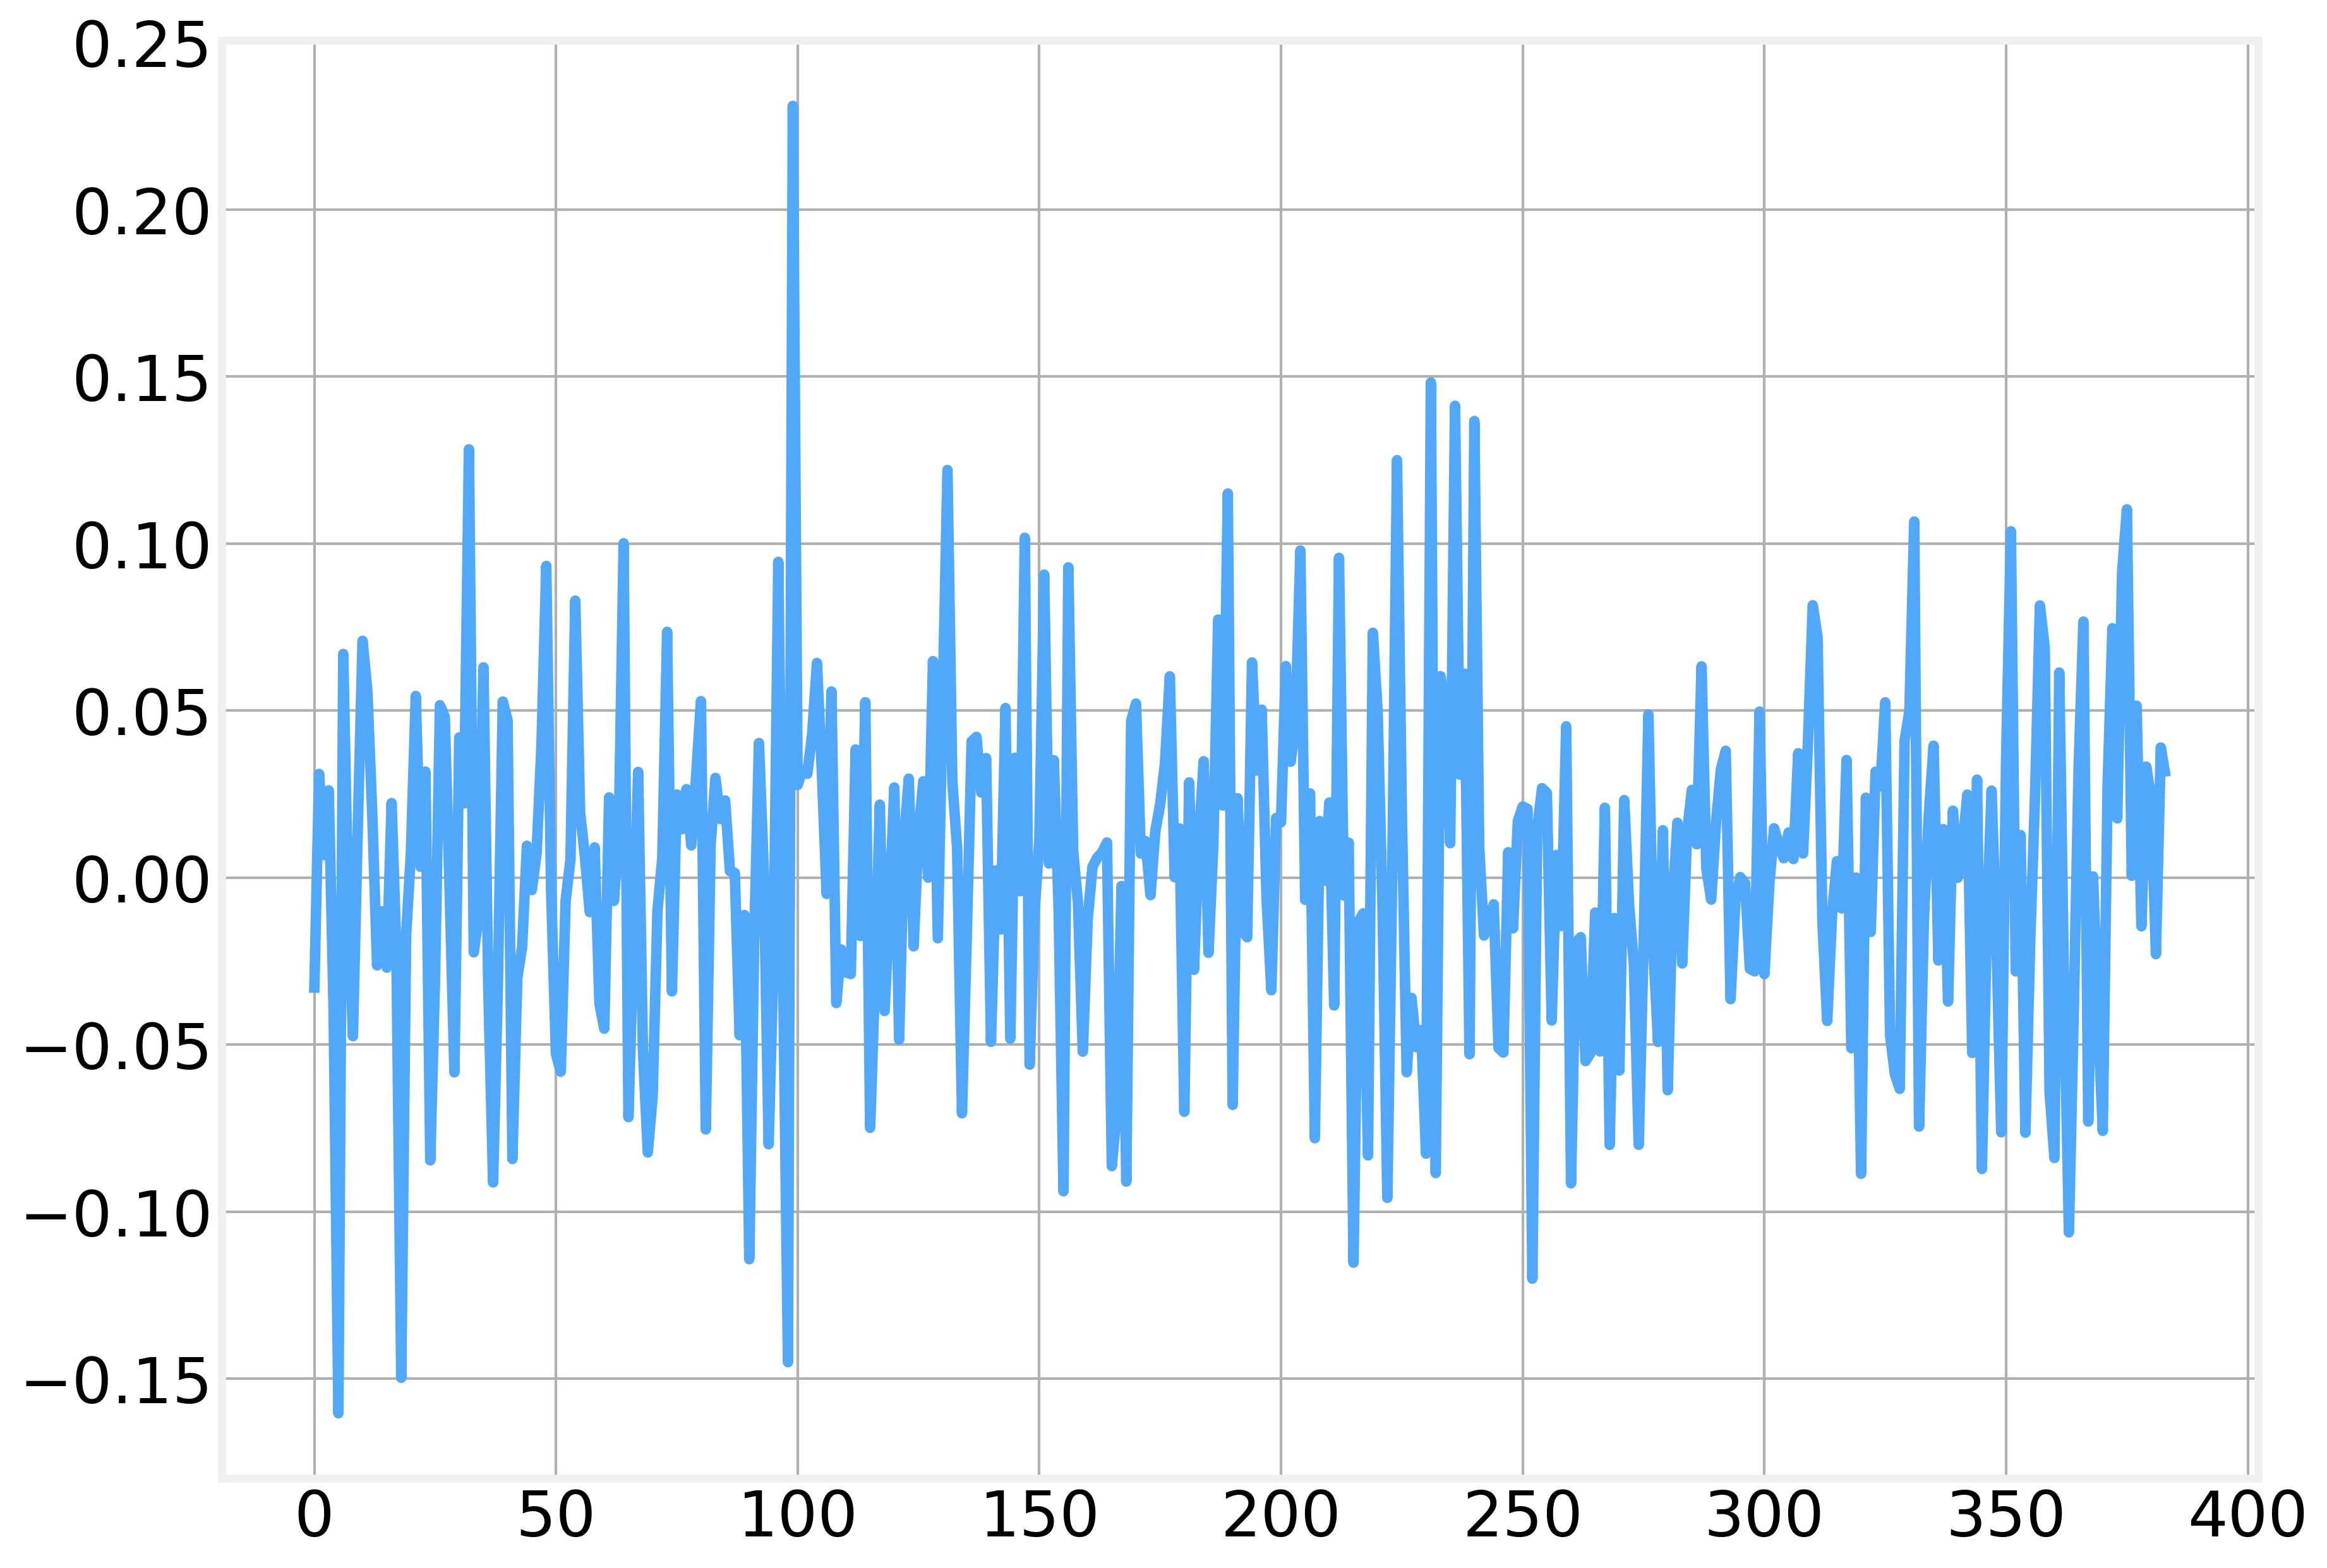

In [7]:
plt.plot(vec[0])

# Build the vector store

Two design decisions worth pointing out:

1. **Chunk size.** Wikipedia passages are already paragraph-sized, so we mostly *don't* chunk further. Over-chunking destroys context.
2. **Persistent vs ephemeral.** For a tutorial, in-memory is fine. For a real app, use `chromadb.PersistentClient(path=...)` so you don't re-embed every restart.

In [8]:
ds = load_dataset('rag-datasets/rag-mini-wikipedia', 'text-corpus', split='passages')

passages = [r['passage'] for r in ds]

print(f'Loaded {len(passages)} passages')
print('Avg length (chars):', int(np.mean([len(p) for p in passages])))
passages[0][:300]

Loaded 3200 passages
Avg length (chars): 389


'Uruguay (official full name in  ; pron.  , Eastern Republic of  Uruguay) is a country located in the southeastern part of South America.  It is home to 3.3 million people, of which 1.7 million live in the capital Montevideo and its metropolitan area.'

Embed the corpus. ~30-60 seconds on CPU for ~3 200 short passages.

In [9]:
BATCH = 64
vecs = []
for i in tqdm(range(0, len(passages), BATCH), desc='Embedding'):
    vecs.append(embedder.encode(passages[i:i+BATCH], show_progress_bar=False))
embeddings = np.vstack(vecs)
print('Embeddings shape:', embeddings.shape)

Embedding:   0%|          | 0/50 [00:00<?, ?it/s]

Embeddings shape: (3200, 384)


In [10]:
client = chromadb.Client(Settings(anonymized_telemetry=False))

# Recreate fresh
if 'wiki' in [c.name for c in client.list_collections()]:
    client.delete_collection('wiki')
collection = client.create_collection('wiki')

# Add in batches — Chroma has limits on single-call size
B = 1000
for i in tqdm(range(0, len(passages), B), desc='Indexing'):
    end = min(i + B, len(passages))
    collection.add(
        ids=[str(j) for j in range(i, end)],
        embeddings=embeddings[i:end].tolist(),
        documents=passages[i:end],
    )

print('Indexed:', collection.count())

Indexing:   0%|          | 0/4 [00:00<?, ?it/s]

Indexed: 3200


# Retrieval

In [11]:
def retrieve(query: str, k: int = 4) -> List[str]:
    qv = embedder.encode([query])
    res = collection.query(query_embeddings=qv.tolist(), n_results=k)
    return res['documents'][0]

for d in retrieve('Who wrote the play Hamlet?'):
    print('•', d[:200], '...\n')

• Portrait of Blaise Pascal ...

• Isaac Newton in 1712. Portrait by Sir James Thornhill. ...

• A discussion of Pascal figures prominently in the movie My Night At Maud's by the French director Ãric Rohmer. ...

• * Mosier, John., "Grant", Palgrave MacMillan, 2006 ISBN 1-4039-7136-6. ...



# Plain RAG chain

Classic recipe: retrieve → stuff into prompt → answer with citations. Two important guardrails:
- The model must say "I don't know" if the context is unhelpful.
- Citations are by passage number, not made-up URLs.

In [12]:
RAG_PROMPT = ChatPromptTemplate.from_messages([
    ('system', 'Answer using ONLY the numbered passages below. '
               'Cite each fact as [#] referring to the passage number. '
               'If the passages do not contain the answer, say so explicitly.'),
    ('user', 'Question: {question}\n\nPassages:\n{ctx}'),
])

def format_ctx(passages: List[str]) -> str:
    return '\n\n'.join(f'[{i+1}] {p}' for i, p in enumerate(passages))

def answer(question: str) -> str:
    ctx = format_ctx(retrieve(question, k=4))
    return (RAG_PROMPT | llm | StrOutputParser()).invoke(
        {'question': question, 'ctx': ctx})

print(answer('Who wrote the play Hamlet?'))

Based on the provided passages, I cannot answer the question about who wrote the play Hamlet. The passages contain information about Blaise Pascal, Isaac Newton, a French film, and a book about Grant, but none of them mention Hamlet or its author.


# Evaluate on the bundled Q&A set

The dataset comes with a small QA test split. We compute exact-match and a relaxed substring-match — neither is perfect for free-form answers, but together they catch most regressions.

In [13]:
qa = load_dataset('rag-datasets/rag-mini-wikipedia', 'question-answer', split='test')

# Sample down for speed
qa_sample = qa.select(range(20))
preds = []

for ex in tqdm(qa_sample, desc='Eval'):
    try:
        preds.append(answer(ex['question']))
    except Exception as e:
        preds.append(f'ERROR: {e}')

def loose_match(pred: str, gold: str) -> bool:
    return gold.lower().strip() in pred.lower()

hits = [loose_match(p, g) for p, g in zip(preds, qa_sample['answer'])]
print(f'Loose-match accuracy: {sum(hits)}/{len(hits)} = {np.mean(hits):.0%}')

Eval:   0%|          | 0/20 [00:00<?, ?it/s]

Loose-match accuracy: 15/20 = 75%


# Tools

RAG is great for facts in a corpus, awful for arithmetic and time. We add two tools, plus expose retrieval as a tool too — that way the model decides when to search vs. when to compute.

In [14]:
@tool
def calculator(expression: str) -> str:
    '''Evaluate a Python arithmetic expression. Use for any math the user asks for.'''
    try:
        # Restrict to safe builtins
        allowed = {'__builtins__': {}}
        return str(eval(expression, allowed, {'abs': abs, 'min': min,
                                              'max': max, 'round': round}))
    except Exception as e:
        return f'error: {e}'

@tool
def now() -> str:
    '''Return the current UTC date and time. Use for any "today/now/current" question.'''
    return datetime.utcnow().isoformat() + 'Z'

@tool
def wiki_search(query: str) -> str:
    '''Search the local Wikipedia index. Use for facts about people, places, events.'''
    return format_ctx(retrieve(query, k=4))

tools = [calculator, now, wiki_search]
tools

[StructuredTool(name='calculator', description='Evaluate a Python arithmetic expression. Use for any math the user asks for.', args_schema=<class 'langchain_core.utils.pydantic.calculator'>, func=<function calculator at 0x12b06d6f0>),
 StructuredTool(name='now', description='Return the current UTC date and time. Use for any "today/now/current" question.', args_schema=<class 'langchain_core.utils.pydantic.now'>, func=<function now at 0x12b06d7a0>),
 StructuredTool(name='wiki_search', description='Search the local Wikipedia index. Use for facts about people, places, events.', args_schema=<class 'langchain_core.utils.pydantic.wiki_search'>, func=<function wiki_search at 0x12efb6820>)]

# The interactive agent

We bind the tools to the LLM and run a small REPL loop. The model decides which tool to call (if any), we execute it, feed the result back, and repeat until the model returns a final answer.

In [15]:
llm_with_tools = llm.bind_tools(tools)
tool_map = {t.name: t for t in tools}

SYSTEM = (
    'You are a careful research assistant. '
    'For factual questions, call wiki_search before answering. '
    'For arithmetic, call calculator. For time questions, call now. '
    'Always cite passage numbers when you used wiki_search.'
)

def chat(question: str, max_loops: int = 5, history=None):
    history = history or [SystemMessage(content=SYSTEM)]
    history.append(HumanMessage(content=question))
    
    for _ in range(max_loops):
        ai = llm_with_tools.invoke(history)
        history.append(ai)

        if not getattr(ai, 'tool_calls', None):
            return ai.content, history
            
        for call in ai.tool_calls:
            try:
                print(f"question:{question}\nCalling tool:{call['name']}\n")
                result = tool_map[call['name']].invoke(call['args'])
            except Exception as e:
                result = f'tool error: {e}'
            history.append({
                'role': 'tool',
                'tool_call_id': call['id'],
                'content': str(result),
            })
    
    return '[max loops reached]', history

In [16]:
for q in [
    'Who wrote the play Hamlet?',
    'What is 217 * 84 + 5?',
    'What is today\'s date?',
    'Tell me about the Apollo 11 mission, then convert 384,400 km to miles.',
]:
    print(f'\nQ: {q}')
    ans, _ = chat(q)
    print(f'A: {ans}')


Q: Who wrote the play Hamlet?
question:Who wrote the play Hamlet?
Calling tool:wiki_search

question:Who wrote the play Hamlet?
Calling tool:wiki_search

question:Who wrote the play Hamlet?
Calling tool:wiki_search

A: The search index doesn't seem to have direct information about Hamlet. However, based on well-established historical knowledge:

**William Shakespeare** wrote the play *Hamlet*. It is one of his most famous tragedies, believed to have been written between 1599 and 1601. The full title is *The Tragedy of Hamlet, Prince of Denmark*, and it tells the story of Prince Hamlet seeking revenge against his uncle Claudius, who murdered Hamlet's father to seize the throne of Denmark.

Q: What is 217 * 84 + 5?
question:What is 217 * 84 + 5?
Calling tool:calculator

A: 217 × 84 + 5 = **18,233**

Q: What is today's date?
question:What is today's date?
Calling tool:now

A: Today's date is **July 8, 2026** (Wednesday). The current time is 20:51:27 UTC.

Q: Tell me about the Apollo 11 m

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>